<div style="text-align: left;">
<table style="width:100%; background-color:transparent;">
  <tr style="background-color:transparent;">
    <td align="center"; style="background-color:transparent;"><a href = "https://joliot.cea.fr/drf/joliot/recherche/neurospin"><img src="https://baobablab.github.io/bhb/images/collaborators/cea.jpg" width="35%"></td>
    <td align="center"; style="background-color:transparent; width: 50%;"><a href = "https://dataia.eu/"><img src="https://github.com/ramp-kits/brain_age_with_site_removal/raw/main/DATAIA-h.png" width="80%"></a></td>
  </tr>
</table> 
</div>

<center><h1>OpenBHB challenge: predicting brain age with site-effect removal</h1></center>

<center><h3>A data challenge on Healthy Controls</h3></center>

<center><i>Antoine Grigis, Benoît Dufumier, Edouard Duchesnay (Université Paris-Saclay, CEA, NeuroSpin), François Caud, Alexandre Gramfort (Université Paris-Saclay, DATAIA) </i></center>


**To download and run this notebook**: download the [full starting kit](https://github.com/ramp-kits/brain_age_with_site_removal), with all the necessary files.


## Software

This starting kit requires Python 3 and the following dependencies:

* `numpy`
* `scipy`
* `nibabel`
* `pandas`
* `scikit-learn`
* `nilearn`
* `matplolib`
* `seaborn`
* `jupyter`
* `progressbar`
* `torch`
* `ramp-workflow`

You can install the dependencies using `pip` with the following command-line:

```
pip install -U -r requirements.txt
```

If you are using `conda`, we provide an `environment.yml` file for similar usage:

```
conda env create -n ramp-brainage-siterm -f environment.yml
```

Then, you can activate/desactivate the conda environment using:

```
conda activate ramp-brainage-siterm
conda deactivate
```

## Introduction: what is this challenge about

Modelling brain development and maturation in the healthy population with Machine Learning (ML) from brain MRI images is a fundamental challenge. Biological processes implied are complex and highly heterogeneous between individuals, comprising both environmental and genetic variability across subjects. As a result, there is a need for large MRI datasets including subjects with a wide range of age. However, these datasets are often multi-sites (i.e images are acquired at different hospitals or acquisition centers across the world) and it induces a strong bias in current MRI data, due to difference between scanners (magnetic field, constructor, gradients, etc.)

Consequently, this challenge aims at building i) robust ML models that can accuratly predict chronological age from brain MRI while ii) removing non-biological site information from MRI images. We have designed this challenge in the context of **representation learning** and it promotes the development of new ML and **Deep Learning** algorithms.

More specifically, aging is associated with grey matter (GM) atrophy. Each year, an adult lose 0.1% of GM. We will try to learn a predictor of the chronological age (true age) using GM derived features on a population of healthy control participants.

Such a predictor provides the expected **brain age** of a subject. Deviation from this expected brain age indicates acceleration or slowdown of the aging process which may be associated with a pathological neurobiological process or protective factor of aging.

The dataset is composed of images coming from various sites, different MRI scanners and acquired under various settings. In order to predict properly the age of participants, one should deal with the **site/scanner effect**.

**Objective:** the models submitted to this challenge must encode the data (i.e. perform dimensionality reduction) such that all biological age features are retained while scanner/acquisition protocol information are removed from the resulting encoded data.

## The data

We propose to use the [openBHB dataset](https://baobablab.github.io/bhb/dataset). This dataset is composed of 3227 training images, 757 validation images (available from command line with `download_data.py` or from [IEEE Dataport](https://ieee-dataport.org/open-access/openbhb-multi-site-brain-mri-dataset-age-prediction-and-debiasing)) and 664 testing images (kept private). The validation set is composed of 2 subsets: an internal set (with images acquired from the same MRI scanners as training images); and an external set (with images acquired with different scanners/protocols as training images). It is used for local testing/debugging (e.g. using `ramp-test`, see below) or for cross-validating hyper-parameters of your model.

### Input data

All data have been preprocessed uniformly and checked. The dataset is composed of T1w images derived features composed of Quasi-Raw, CAT12 VBM, and FreeSurfer:

- Quasi-Raw: minimally preprocessed data were generated using [ANTS bias field correction](https://manpages.debian.org/testing/ants/N4BiasFieldCorrection.1.en.html), [FSL FLIRT](https://fsl.fmrib.ox.ac.uk/fsl/fslwiki/FLIRT) affine registration with 9 degrees of freedom (no shearing) to the isotropic 1mm MNI template, and the application of a brain mask to remove non-brain tissues in the final images.

- CAT12 VBM: Voxel-Based Morphometry (VBM) was performed with [CAT12](http://www.neuro.uni-jena.de/cat). The analysis stream includes non-linear spatial registration to the isotropic 1.5mm MNI template, Gray Matter (GM), White Matter (WM), and CerebroSpinal Fluid (CSF) tissues segmentation, bias correction of intensity non-uniformities, and segmentations modulation by scaling with the amount of volume changes due to spatial registration. VBM is most often applied to investigate the GM. The sensitivity of VBM in the WM is low, and usually, diffusion-weighted imaging is preferred for that purpose. For this reason, only the modulated GM images are shared. Moreover, CAT12 computes GM volumes averaged on the Neuromorphometrics atlas that includes 284 brain cortical and sub-cortical ROIs.

- FreeSurfer: Cortical analysis was performed with [FreeSurfer "recon-all"](https://surfer.nmr.mgh.harvard.edu). The analysis stream includes intensity normalization, skull stripping, segmentation of GM (pial) and WM, hemispheric-based tessellations, topology corrections and inflation, and registration to the **fsaverage** template. From the available morphological measures, the Desikan (68 regions) and Destrieux (148 regions) ROI-based surface area, GM volume, average thickness, thickness standard deviation, integrated rectified mean curvature, integrated rectified gaussian curvature, and intrinsic curvature are computed. The desikan parcellation, the cortical curvature, sulcal indices, and thickness are also available on a ico7 left/right symmetrized mesh with (163842 vertives) derived using FreeSurfer-Xhemi.

The `problem.get_[train|test]_data()` function returns a big matrix of shape $n_{subjects}\times n_{features}$. The features are the concatenation of all modalities: CAT12 VBM (519945 features), Quasi-Raw (1827095 features), FreeSurfer-Xhemi 4 x 2 (left and right hemispheres) channels | 163842 vertices (ico7), CAT12 VBM 284 ROIs (284 features), FreeSurfer Desikan 7 channels | 68 ROIs (476 features), and FreeSurfer 7 channels | 148 ROIs (1036 features)  data leading to a $n_{subjects} \times 3659572$ array. For ROI-based data, the channel and ROI dimensions has been flattened, and for image-based data a GM (for CAT12 VBM) or brain (for Quasi-Raw) mask has been applied using `nilearn.masking.apply_mask`.

A `FeatureExtractor` class is proposed in the `submissions/starting_kit/estimator.py` file that simplify the access of each data bloc. Below you will find some use cases of this functionality:

In [1]:
# path of train and test .tsv
path = ""
import os
import pandas as pd
import numpy as np

def save_filtered_data(path, dataset):
    df = pd.read_csv(os.path.join(path, "data", dataset + ".tsv"), sep="\t")
    x_arr = np.load(os.path.join(path, "data", dataset + ".npy"), mmap_mode="r")
    filtered_df = df[df["site"] == 1]
    y_filtered = filtered_df[["age", "site"]].values
    x_filtered = x_arr[filtered_df.index] 
    filtered_tsv_path = os.path.join(path, "data", f"{dataset}_site_1.tsv")
    filtered_npy_path = os.path.join(path, "data", f"{dataset}_site_1.npy")
    filtered_df.to_csv(filtered_tsv_path, sep="\t", index=False)
    np.save(filtered_npy_path, x_filtered)
    
    print(f"Filtered data saved to: {filtered_tsv_path}")
    print(f"Filtered x_arr saved to: {filtered_npy_path}")

save_filtered_data(path, "train")
save_filtered_data(path, "test")

Filtered data saved to: data\train_site_1.tsv
Filtered x_arr saved to: data\train_site_1.npy
Filtered data saved to: data\test_site_1.tsv
Filtered x_arr saved to: data\test_site_1.npy


**Remark:** `problem.get_test_data()` returns locally (on your computer) the official validation set for this challenge.

### Target labels

The `problem.get_[train|test]_data()` function returns as second element the target vector composed of `age` and `site` information.

In [2]:
import os
import pandas as pd
import numpy as np
import sys
from estimator import FeatureExtractor
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import Dataset, DataLoader

# Need to specify where to find the brain and GM masks using env variables.
os.environ["VBM_MASK"] = "./cat12vbm_space-MNI152_desc-gm_TPM.nii.gz"
os.environ["QUASIRAW_MASK"] = "./quasiraw_space-MNI152_desc-brain_T1w.nii.gz"
# %matplotlib inline
from problem import get_train_data, get_test_data, DatasetHelper

train_dataset = DatasetHelper(data_loader=get_train_data)
X_train, y_train = train_dataset.get_data()
test_dataset = DatasetHelper(data_loader=get_test_data)
X_test, y_test = test_dataset.get_data()

class BrainAgeDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data

    def __len__(self):
        return len(self.X_data)

    def __getitem__(self, idx):
        sample = np.expand_dims(self.X_data[idx], axis=0)
        label = self.y_data[idx,0]
        sample = FeatureExtractor(dtype="quasiraw").transform(sample)
        sample = torch.tensor(sample, dtype=torch.float16)
        sample = sample.squeeze(0)
        sample = sample.squeeze(0)
        label = torch.tensor(label, dtype=torch.float16)
        return sample, label
dataset = BrainAgeDataset(X_train, y_train)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)
for inputs, labels in train_loader:
    print(inputs.shape, labels.shape)
    break

Activate TRAINING mode...
Read TRAIN...
- y size [original]: (3227, 2)
- x size [original]: (3227, 3659572)
Read TEST...
- y size [original]: (757, 2)
- x size [original]: (757, 3659572)
torch.Size([4, 182, 218, 182]) torch.Size([4])


In [3]:
train_loader

In [4]:
class BrainAgeDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data

    def __len__(self):
        return len(self.X_data)

    def __getitem__(self, idx):
        sample = np.expand_dims(self.X_data[idx], axis=0)
        label = self.y_data[idx,0]
        sample = FeatureExtractor(dtype="quasiraw").transform(sample)
        sample = torch.tensor(sample, dtype=torch.float32)
        sample = sample.squeeze(0)
        label = torch.tensor(label, dtype=torch.float32)
        return sample, label
dataset = BrainAgeDataset(X_train, y_train)
train_loader = DataLoader(dataset, batch_size=4, shuffle=True)

class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate, kernel_size=3, stride=1, padding=1):
        super(DenseLayer, self).__init__()
        self.conv = nn.Conv3d(in_channels, growth_rate, kernel_size=kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm3d(growth_rate)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        return out

class DenseBlock(nn.Module):
    def __init__(self, in_channels, growth_rate, num_layers):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        for layer in self.block:
            new_features = layer(x)
            x = torch.cat([x, new_features], 1)
        return x

class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.conv = nn.Conv3d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm3d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.AvgPool3d(kernel_size=2, stride=2)

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.pool(out)
        return out

class DenseNet3D(nn.Module):
    def __init__(self, input_channels=1, num_classes=1, growth_rate=12, block_config=(6, 12, 24, 16)):
        super(DenseNet3D, self).__init__()
        
        # Initial convolution
        self.conv0 = nn.Conv3d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn0 = nn.BatchNorm3d(64)
        self.relu0 = nn.ReLU(inplace=True)
        self.pool0 = nn.MaxPool3d(kernel_size=3, stride=2, padding=1)

        # Dense blocks with transition layers
        num_channels = 64
        self.dense1 = DenseBlock(num_channels, growth_rate, block_config[0])
        num_channels += block_config[0] * growth_rate
        self.trans1 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2
        
        self.dense2 = DenseBlock(num_channels, growth_rate, block_config[1])
        num_channels += block_config[1] * growth_rate
        self.trans2 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2
        
        self.dense3 = DenseBlock(num_channels, growth_rate, block_config[2])
        num_channels += block_config[2] * growth_rate
        self.trans3 = TransitionLayer(num_channels, num_channels // 2)
        num_channels = num_channels // 2
        
        self.dense4 = DenseBlock(num_channels, growth_rate, block_config[3])
        num_channels += block_config[3] * growth_rate
        self.fc = nn.Sequential(
            nn.Linear(58350, num_channels),
            nn.Linear(num_channels, num_classes)
        )

    def forward(self, x):
        x = self.relu0(self.bn0(self.conv0(x)))
        x = self.pool0(x)

        x = self.dense1(x)
        x = self.trans1(x)

        x = self.dense2(x)
        x = self.trans2(x)

        x = self.dense3(x)
        x = self.trans3(x)

        x = self.dense4(x)
        
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNet3D(input_channels=1, num_classes=1).to(device)

criterion = nn.MSELoss().to(device)  
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print("Using device:", device)

Using device: cuda


C:\Users\Yuning\anaconda3\envs\pt-gpu\Lib\site-packages\torch_lr_finder\lr_finder.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Yuning\anaconda3\envs\pt-gpu\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([4, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
 75%|███████▌  | 75/100 [07:42<02:34,  6.16s/it]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.56E-05


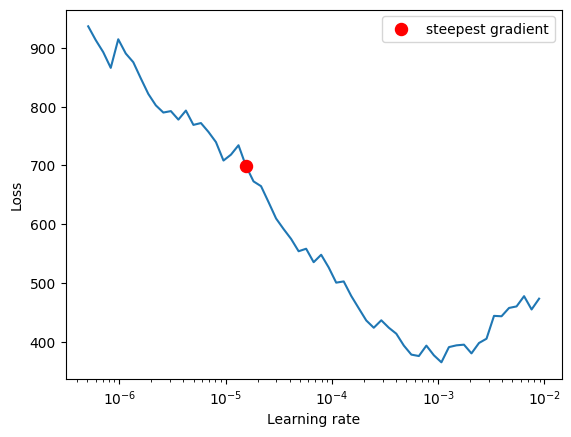

In [5]:
import torch.optim as optim
from torch_lr_finder import LRFinder
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DenseNet3D(input_channels=1, num_classes=1).to(device) 
criterion = nn.MSELoss().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-7)              
lr_finder = LRFinder(model, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=1, num_iter=100)      
lr_finder.plot(suggest_lr=True)                                
suggested_lr = lr_finder.history["lr"][np.argmin(lr_finder.history["loss"])]
lr_finder.reset()                                               



In [6]:
num_epochs = 10
optimizer = optim.Adam(model.parameters(), lr=suggested_lr)
total_steps = num_epochs * len(train_loader)
scheduler = OneCycleLR(optimizer,
                       max_lr=suggested_lr,
                       total_steps=total_steps,
                       pct_start=0.3,
                       anneal_strategy="cos",
                       final_div_factor=1e2)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    # 用 enumerate 获取批次索引 i（从 0 开始），len(train_loader) 是总批次数
    for i, (inputs, labels) in enumerate(train_loader, start=1):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Batch [{i}/{len(train_loader)}], "
              f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} finished — Loss: {epoch_loss:.4f}")


Epoch [1/10], Batch [1/807], Loss: 1136.3070
Epoch [1/10], Batch [2/807], Loss: 1307.5972
Epoch [1/10], Batch [3/807], Loss: 1035.3704
Epoch [1/10], Batch [4/807], Loss: 736.7935
Epoch [1/10], Batch [5/807], Loss: 507.6735
Epoch [1/10], Batch [6/807], Loss: 597.9103
Epoch [1/10], Batch [7/807], Loss: 710.2948
Epoch [1/10], Batch [8/807], Loss: 774.9079
Epoch [1/10], Batch [9/807], Loss: 823.1598
Epoch [1/10], Batch [10/807], Loss: 613.6327
Epoch [1/10], Batch [11/807], Loss: 448.0048
Epoch [1/10], Batch [12/807], Loss: 284.7625
Epoch [1/10], Batch [13/807], Loss: 80.0956
Epoch [1/10], Batch [14/807], Loss: 872.3107
Epoch [1/10], Batch [15/807], Loss: 30.6157
Epoch [1/10], Batch [16/807], Loss: 727.0100
Epoch [1/10], Batch [17/807], Loss: 1034.7380
Epoch [1/10], Batch [18/807], Loss: 50.0030
Epoch [1/10], Batch [19/807], Loss: 599.9100
Epoch [1/10], Batch [20/807], Loss: 29.9255
Epoch [1/10], Batch [21/807], Loss: 12.1488
Epoch [1/10], Batch [22/807], Loss: 426.5491
Epoch [1/10], Batch 

C:\Users\Yuning\anaconda3\envs\pt-gpu\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([3])) that is different to the input size (torch.Size([3, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/10], Batch [807/807], Loss: 518.6125
Epoch 1/10 finished — Loss: 248.2272
Epoch [2/10], Batch [1/807], Loss: 379.5911
Epoch [2/10], Batch [2/807], Loss: 25.9733
Epoch [2/10], Batch [3/807], Loss: 908.1929
Epoch [2/10], Batch [4/807], Loss: 76.8579
Epoch [2/10], Batch [5/807], Loss: 62.0341
Epoch [2/10], Batch [6/807], Loss: 33.9602
Epoch [2/10], Batch [7/807], Loss: 85.2198
Epoch [2/10], Batch [8/807], Loss: 48.3090
Epoch [2/10], Batch [9/807], Loss: 143.0827
Epoch [2/10], Batch [10/807], Loss: 30.9154
Epoch [2/10], Batch [11/807], Loss: 77.8170
Epoch [2/10], Batch [12/807], Loss: 73.9905
Epoch [2/10], Batch [13/807], Loss: 61.7949
Epoch [2/10], Batch [14/807], Loss: 28.7919
Epoch [2/10], Batch [15/807], Loss: 15.7441
Epoch [2/10], Batch [16/807], Loss: 9.6550
Epoch [2/10], Batch [17/807], Loss: 94.5864
Epoch [2/10], Batch [18/807], Loss: 469.9157
Epoch [2/10], Batch [19/807], Loss: 33.4588
Epoch [2/10], Batch [20/807], Loss: 377.4464
Epoch [2/10], Batch [21/807], Loss: 452.64

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = BrainAgeDataset(X_test, y_test)
test_loader = DataLoader(dataset, batch_size=3, shuffle=True)

model.eval()  # Set model to evaluation mode (no gradients)
test_loss = 0.0
num_correct = 0
num_total = 0
total_absolute_error = 0.0

with torch.no_grad():  # Disable gradient calculation for testing
    for inputs, labels in test_loader:  # Assuming test_loader is defined
    # Move data to the same device as the model
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)  # Forward pass
        
        # Calculate loss
        loss = criterion(outputs.squeeze(), labels)
        test_loss += loss.item()
        num_total += labels.size(0) 
        absolute_error = torch.abs(outputs.squeeze() - labels)
        total_absolute_error += absolute_error.sum().item()
avg_test_loss = test_loss / len(test_loader)
print(f"Test Loss: {avg_test_loss}")
mae = total_absolute_error / num_total
print(f"Mean Absolute Error (MAE): {mae}")

Test Loss: 280.0234705318643
Mean Absolute Error (MAE): 9.033699241132368


In [5]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}    Trainable params: {trainable_params:,}")


Total params: 26,922,492    Trainable params: 26,922,492
